## Математические методы биоинформатики

### Home work 5. Задача обучения с учителем - классификация.

### Задание.

В файле *gliomas_proteomics.xlsx* представлены протеомные данные пациентов с опухолями головного мозга. Необходимо разработать классификатор для предсказания одного из трех подтипов опухоли (целевая переменная *diagnoses.primary_diagnosis*): *'Oligodendroglioma, anaplastic'*, *'Astrocytoma, anaplastic'* или *'Mixed glioma'*.

Выполните следующие задания:

1) Проведите полный цикл предварительной обработки данных.  

2) Сформируйте два подмножества признаков: subset1 (все признаки) и subset2 (признаки, статистически значимо отличающиеся между классами в результате множественного тестирования).

3) Примените рассмотренные на лекции модели классификации (логистическая регрессия, kNN, SVM, дерево решений, случайный лес, экстремально случайный лес) к полученным наборам признаков (subset1 и subset2).  
- Выясните, какие метрики качества классификации предпочтительно использовать в условиях дисбаланса классов, выберите 3 основные.  
- Для каждой модели выполните подбор гиперпараметров с помощью Байесовской оптимизации.  
- Сформируйте таблицу значений выбранных метрик качества для рассматриваемых моделей и подмножеств признаков. Метрики должны быть вычислены на обучающей выборке с помощью кросс-валидации. Выберите лучшую модель.

4) Для лучшей модели вычислите метрики качества на тестовой выборке. Постройте матрицу ошибок, вычислите чувствительность и специфичность модели для каждого класса. Сделайте выводы.

## 1) Полный цикл предварительной обработки данных

**Пункт задания 1:** провести полный цикл предварительной обработки данных для задачи классификации.

In [2]:
# Импортируем библиотеки
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import kruskal, chi2_contingency
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import optuna
from optuna.samplers import TPESampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Читаем данные
# Используем путь от корня проекта, чтобы избежать ошибок FileNotFoundError.
data_path = 'gliomas_proteomics.xlsx'
df = pd.read_excel(data_path)

print(f'Размер исходной таблицы: {df.shape}')
print('\nПервые 5 строк исходного датасета:')
display(df.head())

print('Классы в полном наборе данных:')
print(df['diagnoses.primary_diagnosis'].value_counts(dropna=False))


Размер исходной таблицы: (429, 491)

Первые 5 строк исходного датасета:


,cases.submitter_id,demographic.age,demographic.gender,1433BETA,1433EPSILON,1433ZETA,4EBP1,4EBP1_pS65,4EBP1_pT37T46,4EBP1_pT70,...,XRCC1,YAP,YAP_pS127,YB1,YB1_pS102,YTHDF2,YTHDF3,ZAP-70,ZEB1,diagnoses.primary_diagnosis
0,TCGA-FG-A4MY,44,0.0,0.069264,0.37295,-0.519320,-0.60410,-0.379530,0.49439,-0.210410,...,-0.27421,-0.275680,-1.0934,-0.068482,-0.079755,-0.261117,-0.671932,-1.558470,0.392366,Mixed glioma
1,TCGA-DB-A4X9,33,0.0,0.182310,0.33884,-0.035191,-0.53742,-0.058336,-0.45942,-0.375550,...,-0.20808,-0.045655,-1.2539,-0.138460,-0.024303,-0.180114,-0.448852,-1.696286,0.763768,Mixed glioma
2,TCGA-FG-7634,28,1.0,0.299810,0.26236,-0.553070,-0.35459,-0.068374,0.63526,-0.113780,...,-0.38825,-0.504620,-1.1561,-0.110080,0.010908,-0.350363,-0.438118,-1.272206,0.418899,"Oligodendroglioma, NOS"
3,TCGA-HT-7467,54,1.0,0.315760,0.13007,-0.151660,-1.25110,-0.198960,-0.13675,-0.124820,...,-0.50708,-0.604310,-1.6397,-0.262980,-0.047955,-0.668674,-1.067962,-1.451437,-0.318740,"Oligodendroglioma, NOS"
4,TCGA-HT-7689,58,0.0,0.186980,0.29977,-0.455300,-0.54562,-0.140740,0.63750,-0.059809,...,-0.48420,-0.442580,-1.3354,-0.380810,-0.158720,-0.429271,-0.728330,-1.444349,-0.157615,"Oligodendroglioma, NOS"


Классы в полном наборе данных:
diagnoses.primary_diagnosis
Mixed glioma                     114
Oligodendroglioma, NOS           103
Astrocytoma, anaplastic          100
Oligodendroglioma, anaplastic     64
Astrocytoma, NOS                  47
Not Reported                       1
Name: count, dtype: int64


In [3]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 491 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    cases.submitter_id            object 
 1    demographic.age               object 
 2    demographic.gender            float64
 3    1433BETA                      float64
 4    1433EPSILON                   float64
 5    1433ZETA                      float64
 6    4EBP1                         float64
 7    4EBP1_pS65                    float64
 8    4EBP1_pT37T46                 float64
 9    4EBP1_pT70                    float64
 10   53BP1                         float64
 11   ACC_pS79                      float64
 12   ACC1                          float64
 13   AceCS1                        float64
 14   ACETYLATUBULINLYS40           float64
 15   ACSL1                         float64
 16   ACVRL1                        float64
 17   ADAR1                         float64
 18   AKT     

In [4]:
df.describe(include=['object'])

,cases.submitter_id,demographic.age,diagnoses.primary_diagnosis
count,429,429,429
unique,429,60,6
top,TCGA-FG-A4MY,38,Mixed glioma
freq,1,20,114


In [5]:
df.describe()

,demographic.gender,1433BETA,1433EPSILON,1433ZETA,4EBP1,4EBP1_pS65,4EBP1_pT37T46,4EBP1_pT70,53BP1,ACC_pS79,...,XPF,XRCC1,YAP,YAP_pS127,YB1,YB1_pS102,YTHDF2,YTHDF3,ZAP-70,ZEB1
count,428.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,...,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000,429.000000
mean,0.553738,0.237228,0.240085,-0.165618,-0.541121,0.020219,0.473513,-0.189804,-0.261259,-0.103433,...,-0.004075,-0.419654,-0.335977,-1.054751,-0.294947,0.096646,-0.409404,-0.567469,-1.468352,0.435526
std,0.497686,0.229521,0.157748,0.388016,0.278716,0.278939,0.662886,0.185555,0.482871,0.508916,...,0.286333,0.215699,0.214309,0.505382,0.226916,0.172705,0.333183,0.353189,0.153834,0.440550
min,0.000000,-0.463410,-0.206880,-0.948180,-1.441200,-0.623120,-1.307600,-0.791600,-3.036900,-2.219800,...,-0.652098,-1.412600,-0.901300,-2.604200,-0.886730,-0.488710,-1.798104,-2.304936,-1.782641,-0.772817
25%,0.000000,0.092523,0.130070,-0.455300,-0.717920,-0.177760,0.042781,-0.307900,-0.577850,-0.396590,...,-0.186547,-0.535460,-0.446930,-1.339000,-0.463690,-0.023191,-0.619012,-0.748051,-1.559122,0.123920
50%,1.000000,0.214410,0.220740,-0.242200,-0.562610,-0.024087,0.503430,-0.211770,-0.303040,-0.111480,...,-0.040032,-0.415610,-0.355270,-1.043500,-0.296450,0.076218,-0.412148,-0.561020,-1.493793,0.423228
75%,1.000000,0.342520,0.326850,0.055315,-0.393770,0.165340,0.937080,-0.096552,0.046037,0.166000,...,0.177849,-0.306040,-0.255120,-0.781120,-0.146540,0.194680,-0.208339,-0.343249,-1.408252,0.680083
max,1.000000,1.221700,0.813990,1.281000,1.152000,1.133100,2.393300,1.001500,1.394000,2.107100,...,1.040282,0.465820,1.398700,1.548700,0.929920,0.898810,0.762228,0.659365,-0.305035,2.088468


In [6]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [7]:
print(df.nunique())

cases.submitter_id             429
demographic.age                 60
demographic.gender               2
1433BETA                       426
1433EPSILON                    427
                              ... 
YTHDF2                         429
YTHDF3                         429
ZAP-70                         429
ZEB1                           429
diagnoses.primary_diagnosis      6
Length: 491, dtype: int64


In [8]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

cases.submitter_id                0
demographic.age                   0
demographic.gender                1
1433BETA                          0
1433EPSILON                       0
1433ZETA                          0
4EBP1                             0
4EBP1_pS65                        0
4EBP1_pT37T46                     0
4EBP1_pT70                        0
53BP1                             0
ACC_pS79                          0
ACC1                              0
AceCS1                            0
ACETYLATUBULINLYS40               0
ACSL1                             0
ACVRL1                            0
ADAR1                             0
AKT                               0
AKT_pS473                         0
AKT_pT308                         0
Akt2                              0
Akt2_pS474                        0
ALKBH5                            0
ALPHACATENIN                    171
Ambra1_pS52                       0
AMPK-a2_pS345                     0
AMPKALPHA                   

**Вывод по пункту 1 (шаг 1):**  Видно, что в датасете есть лишние классы диагноза, которые не входят в постановку задачи, и есть признаки, требующие очистки (пропуски и технические столбцы).

In [9]:
# Оставляем только классы из задания
allowed_classes = [
    'Oligodendroglioma, anaplastic',
    'Astrocytoma, anaplastic',
    'Mixed glioma'
]

df = df[df['diagnoses.primary_diagnosis'].isin(allowed_classes)].copy()

# Удаляем полные дубликаты строк
n_duplicates = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Удаляем столбцы, где все значения пропущены
full_empty_cols = [col for col in df.columns if df[col].isna().all()]
if full_empty_cols:
    df = df.drop(columns=full_empty_cols)

# Удаляем явный идентификатор пациента (утечка информации)
if 'cases.submitter_id' in df.columns:
    df = df.drop(columns=['cases.submitter_id'])

# Преобразуем возраст в числовой формат (если есть строковые значения)
if 'demographic.age' in df.columns:
    df['demographic.age'] = pd.to_numeric(df['demographic.age'], errors='coerce')

# Формируем X и y
target_col = 'diagnoses.primary_diagnosis'
X = df.drop(columns=[target_col])
y = df[target_col].copy()

# Разделяем на train/test с сохранением долей классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Удаляем признаки с очень большим уровнем пропусков (по train, чтобы не было утечки)
# чтобы тест не влиял принятие решения об удалении признаков
missing_ratio_train = X_train.isna().mean() # датасет где посчитали доолю пропусков
high_missing_cols = missing_ratio_train[missing_ratio_train > 0.7].index.tolist()# список признаков с пропусками больше 70%
if high_missing_cols:
    X_train = X_train.drop(columns=high_missing_cols)
    X_test = X_test.drop(columns=high_missing_cols)

# Удаляем константные признаки (по train)
constant_cols = [col for col in X_train.columns if X_train[col].nunique(dropna=False) <= 1]
if constant_cols:
    X_train = X_train.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)

print('Размер после фильтрации классов:', df.shape)
print(f'Удалено полных дубликатов строк: {n_duplicates}')
print(f'Удалено полностью пустых столбцов: {len(full_empty_cols)}')
print(f'Удалено столбцов с >70% пропусков (по train): {len(high_missing_cols)}')
print(f'Удалено константных столбцов (по train): {len(constant_cols)}')

print('\nРаспределение классов после фильтрации:')
print(y.value_counts())
print('\nРазмеры train/test после очистки признаков:')
print(X_train.shape, X_test.shape)

print('\nДоля пропусков в train (топ-10 признаков):')
missing_top = X_train.isna().mean().sort_values(ascending=False).head(10)
print(missing_top)

Размер после фильтрации классов: (278, 461)
Удалено полных дубликатов строк: 0
Удалено полностью пустых столбцов: 29
Удалено столбцов с >70% пропусков (по train): 0
Удалено константных столбцов (по train): 0

Распределение классов после фильтрации:
diagnoses.primary_diagnosis
Mixed glioma                     114
Astrocytoma, anaplastic          100
Oligodendroglioma, anaplastic     64
Name: count, dtype: int64

Размеры train/test после очистки признаков:
(222, 460) (56, 460)

Доля пропусков в train (топ-10 признаков):
PARP1              0.599099
ALPHACATENIN       0.400901
demographic.age    0.000000
P53                0.000000
PAR                0.000000
PAK4               0.000000
PAK1               0.000000
PAICS              0.000000
PAI1               0.000000
p90RSK_pT573       0.000000
dtype: float64


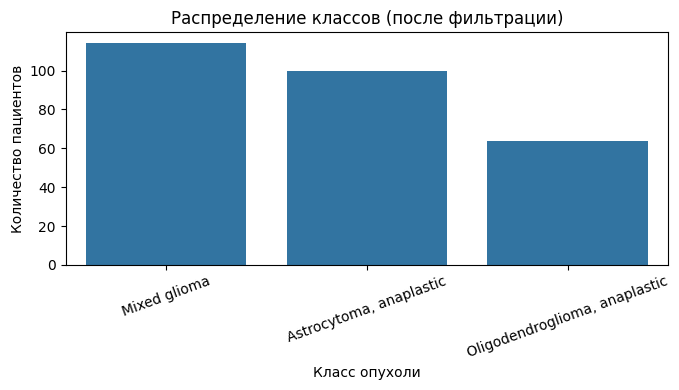

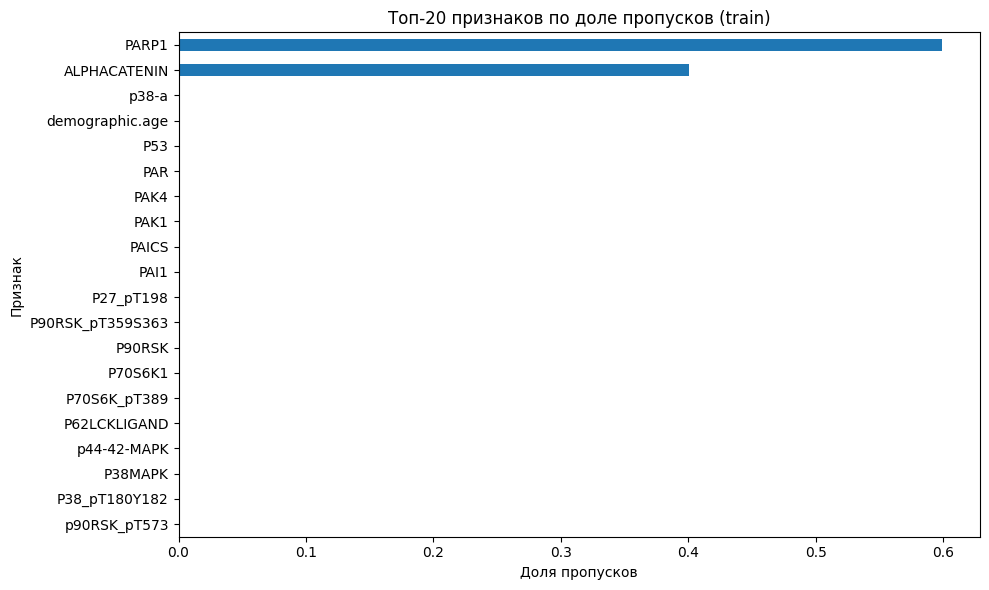

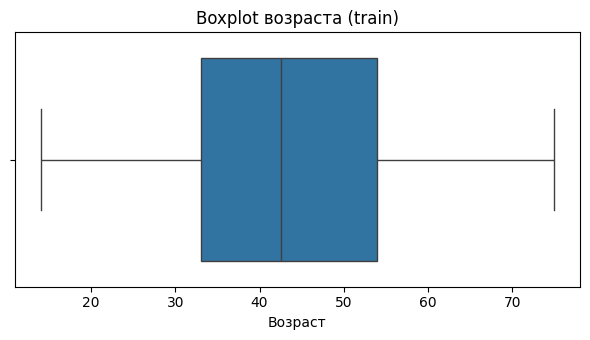

In [10]:
# Визуализации 

# 1) Дисбаланс классов
plt.figure(figsize=(7, 4))
sns.countplot(x=y)
plt.title('Распределение классов (после фильтрации)')
plt.xlabel('Класс опухоли')
plt.ylabel('Количество пациентов')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 2) Топ-20 признаков по доле пропусков в train
missing_share = X_train.isna().mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
missing_share.sort_values().plot(kind='barh')
plt.title('Топ-20 признаков по доле пропусков (train)')
plt.xlabel('Доля пропусков')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# 3) Боксплот для возраста 
if 'demographic.age' in X_train.columns:
    plt.figure(figsize=(6, 3.5))
    sns.boxplot(x=X_train['demographic.age'])
    plt.title('Boxplot возраста (train)')
    plt.xlabel('Возраст')
    plt.tight_layout()
    plt.show()

 Масштабирование числовых признаков, импутация, one hot остается в ML-пайплайне (`StandardScaler`) и применяется корректно внутри кросс-валидации.

## 2) Формирование subset1 и subset2

**Пункт задания 2:** сформировать два подмножества признаков: `subset1` (все признаки) и `subset2` (признаки, статистически значимо отличающиеся между классами с поправкой на множественное тестирование).

+ добавить возраст как категорию и хи квадрат

In [ ]:
# Делим признаки на числовые и категориальные на обучающей выборке
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

# subset1: все признаки
subset1_cols = X_train.columns.tolist()

# subset2: статистически значимые признаки (тесты на train)
# Для числовых признаков используем критерий Краскела-Уоллиса:
# - 3 независимые группы (3 класса)
# - распределения могут быть ненормальными
# Для категориальных признаков используем критерий хи-квадрат независимости.

pvals = []
features_tested = []

y_train_series = pd.Series(y_train).reset_index(drop=True)
X_train_reset = X_train.reset_index(drop=True)

for col in num_cols:
    temp = pd.DataFrame({'x': X_train_reset[col], 'y': y_train_series}).dropna()
    groups = [temp.loc[temp['y'] == cls, 'x'].values for cls in allowed_classes]
    if all(len(g) >= 3 for g in groups):
        try:
            stat, p = kruskal(*groups)
            pvals.append(p)
            features_tested.append(col)
        except ValueError:
            pass


# Поправка на множественное тестирование (FDR Benjamini-Hochberg)
reject, pvals_corr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

stats_df = pd.DataFrame({
    'feature': features_tested,
    'p_value': pvals,
    'p_value_fdr_bh': pvals_corr,
    'significant': reject
}).sort_values('p_value_fdr_bh')

subset2_cols = stats_df.loc[stats_df['significant'], 'feature'].tolist()

print(f'Число признаков в subset1: {len(subset1_cols)}')
print(f'Число признаков в subset2: {len(subset2_cols)}')
print('\nТоп-10 признаков с минимальным скорректированным p-value:')
display(stats_df.head(10))

Число признаков в subset1: 460
Число признаков в subset2: 129

Топ-10 признаков с минимальным скорректированным p-value:


,feature,p_value,p_value_fdr_bh,significant
215,HMHA1,4.966481e-12,2.284581e-09,True
212,Hexokinase-II,2.518017e-11,5.791439e-09,True
413,SYK,1.470287e-10,2.254440e-08,True
87,CD44,3.872205e-10,4.453035e-08,True
267,MMP14,5.340339e-09,4.913112e-07,True
438,VAV1,8.478259e-09,5.571428e-07,True
229,IRF-3,7.719232e-09,5.571428e-07,True
30,AR,1.839002e-08,1.057426e-06,True
11,ACC1,5.900919e-07,3.016025e-05,True
20,Akt2,7.237528e-07,3.329263e-05,True


In [12]:
cat_cols

[]

In [15]:
subset2_cols

['HMHA1',
 'Hexokinase-II',
 'SYK',
 'CD44',
 'MMP14',
 'VAV1',
 'IRF-3',
 'AR',
 'ACC1',
 'Akt2',
 'ANNEXIN1',
 'Vinculin',
 'IRS1',
 'RPA32',
 'FASN',
 'CD45',
 'PKA-a',
 'CD49B',
 'RSK1',
 'ARID1A',
 'HER3',
 'P38MAPK',
 'DJ1',
 'MTSS1',
 'HES1',
 'UBAC1',
 'STAT3_pY705',
 'Grp75',
 'ACC_pS79',
 'TRAP1',
 'YAP_pS127',
 'SDHA',
 'PREX1',
 'Melanoma-gp100',
 'Atg4B',
 'BAX',
 'YAP',
 'DRP1',
 'ALPHACATENIN',
 'Cyclin-D3',
 'PHGDH',
 'PRDX1',
 'B7-H3',
 'IMP3',
 'PARG',
 'b-Actin',
 'SOD2',
 'FAK',
 'RAB11',
 'CD38',
 'HER3_pY1289',
 'INPP4B',
 'ERK2',
 'Cox-IV',
 'Enolase-1',
 'COG3',
 'S100A4',
 'FN14',
 'SMAC',
 'CYCLINB1',
 'PAR',
 'Calnexin',
 'GSK-3B',
 'BAD_pS112',
 '1433EPSILON',
 'MTCO1',
 'SHP2',
 'Cyclophilin-F',
 'STING',
 'MITF',
 'PTEN',
 'Cox2',
 '53BP1',
 'MTOR',
 'PDK1',
 'S6_pS235S236',
 'ERRalpha',
 'PDHK1',
 'CKIT',
 'PDH',
 'PDHA1',
 'P27_pT198',
 'MR1',
 'MCT4',
 'CD4',
 'Hexokinase-I',
 'XIAP',
 'Enolase-2',
 'Jagged1',
 'TIGAR',
 'cGAS',
 'Patched',
 'Connexin-4

## 3) Обучение моделей, выбор метрик, Байесовская оптимизация

**Пункт задания 3:** применить модели классификации (логистическая регрессия, kNN, SVM, дерево решений, случайный лес, экстремально случайный лес) к `subset1` и `subset2`, выбрать 3 лучшие метрики для дисбаланса классов, подобрать гиперпараметры Байесовской оптимизацией, получить таблицу CV-метрик и выбрать лучшую модель.

Выбранные метрики:
- `balanced_accuracy` — учитывает дисбаланс классов;
- `f1_macro` — одинаково учитывает качество по всем классам;
- `roc_auc_ovr_weighted` — устойчивый вероятностный показатель для мультикласса (one-vs-rest, с весами классов).

макро и вейтед

cikcit opt

разные ядра svm

In [ ]:
# Кодируем целевую переменную числами (удобно для ROC-AUC)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
class_names = label_encoder.classes_

# Настройка кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) #данные перемешиваются случайно

# Словарь наборов признаков
feature_subsets = {
    'subset1_all_features': subset1_cols,
    'subset2_significant_features': subset2_cols 
}
# Общий препроцессор: импутация + масштабирование числовых, импутация + OHE категориальных
# Примечание: OHE нужен для категориальных признаков, scaler важен для LR/kNN/SVM.
def make_preprocessor(selected_cols):
    X_part = X_train[selected_cols]
    num_part = X_part.select_dtypes(include='number').columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_part)
        ],
        remainder='drop'
    )
    return preprocessor

# Пространства гиперпараметров для Optuna
# Оптимизируем по macro-F1 (главная метрика для выбора лучшей модели).
def suggest_model(trial, model_name):
    if model_name == 'LogisticRegression':
        # C: коэффициент обратной регуляризации (меньше C -> регуляризация сильнее)
        c = trial.suggest_float('C', 1e-3, 100.0, log=True)
        model = LogisticRegression(
            C=c,
            max_iter=3000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=RANDOM_STATE
        )

    elif model_name == 'KNN':
        # n_neighbors: число соседей; weights: схема голосования; p: 1-Manhattan, 2-Euclidean
        n_neighbors = trial.suggest_int('n_neighbors', 3, 25)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        p = trial.suggest_int('p', 1, 2)
        model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            p=p
        )

    elif model_name == 'SVM':
        # C: штраф за ошибки; gamma: ширина RBF-ядра (локальность влияния точек)
        c = trial.suggest_float('C', 1e-2, 100.0, log=True)
        gamma = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
        model = SVC(
            C=c,
            gamma=gamma,
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )

    elif model_name == 'DecisionTree':
        # max_depth: глубина дерева; min_samples_split/min_samples_leaf: контроль переобучения
        max_depth = trial.suggest_int('max_depth', 2, 25)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )

    elif model_name == 'RandomForest':
        # n_estimators: число деревьев; max_depth/min_samples_*: сложность и устойчивость ансамбля
        n_estimators = trial.suggest_int('n_estimators', 100, 500)
        max_depth = trial.suggest_int('max_depth', 3, 30)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == 'ExtraTrees':
        # n_estimators: число деревьев; max_depth/min_samples_*: сложность, разбиения более случайные
        n_estimators = trial.suggest_int('n_estimators', 100, 500)
        max_depth = trial.suggest_int('max_depth', 3, 30)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        model = ExtraTreesClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:
        raise ValueError('Unknown model name')

    return model

model_names = ['LogisticRegression', 'KNN', 'SVM', 'DecisionTree', 'RandomForest', 'ExtraTrees']

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr_weighted': 'roc_auc_ovr_weighted'
}

results = []
best_objects = {}  # будем хранить лучший пайплайн для каждой пары (subset, model)

for subset_name, selected_cols in feature_subsets.items():
    print(f'\n===== {subset_name} =====')
    preprocessor = make_preprocessor(selected_cols)

    X_train_subset = X_train[selected_cols]

    for model_name in model_names:
        print(f'Оптимизация: {model_name}')

        def objective(trial):
            model = suggest_model(trial, model_name)
            pipe = Pipeline([
                ('prep', preprocessor),
                ('model', model)
            ])

            cv_res = cross_validate(
                pipe,
                X_train_subset,
                y_train_enc,
                cv=cv,
                scoring='f1_macro',
                n_jobs=-1
            )
            return float(np.mean(cv_res['test_score']))

        study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
        study.optimize(objective, n_trials=20, show_progress_bar=False)

        best_model = suggest_model(optuna.trial.FixedTrial(study.best_params), model_name)
        best_pipe = Pipeline([
            ('prep', preprocessor),
            ('model', best_model)
        ])

        cv_scores = cross_validate(
            best_pipe,
            X_train_subset,
            y_train_enc,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        row = {
            'subset': subset_name,
            'model': model_name,
            'balanced_accuracy_cv_mean': np.mean(cv_scores['test_balanced_accuracy']),
            'f1_macro_cv_mean': np.mean(cv_scores['test_f1_macro']),
            'roc_auc_ovr_weighted_cv_mean': np.mean(cv_scores['test_roc_auc_ovr_weighted']),
            'best_params': study.best_params
        }
        results.append(row)
        best_objects[(subset_name, model_name)] = best_pipe

results_df = pd.DataFrame(results).sort_values('f1_macro_cv_mean', ascending=False).reset_index(drop=True)
display(results_df[['subset', 'model', 'balanced_accuracy_cv_mean', 'f1_macro_cv_mean', 'roc_auc_ovr_weighted_cv_mean']])

best_row = results_df.iloc[0]
best_subset_name = best_row['subset']
best_model_name = best_row['model']
print('\nЛучшая комбинация по f1_macro (CV):')
print(best_row[['subset', 'model', 'f1_macro_cv_mean', 'balanced_accuracy_cv_mean', 'roc_auc_ovr_weighted_cv_mean']])

[I 2026-04-27 11:19:01,051] A new study created in memory with name: no-name-1c447fe3-b48a-4d32-81f1-166478e7de2f



===== subset1_all_features =====
Оптимизация: LogisticRegression


[I 2026-04-27 11:19:03,028] Trial 0 finished with value: 0.4992470191835894 and parameters: {'C': 0.07459343285726547}. Best is trial 0 with value: 0.4992470191835894.
[I 2026-04-27 11:19:04,508] Trial 1 finished with value: 0.4648151168142679 and parameters: {'C': 56.69849511478853}. Best is trial 0 with value: 0.4992470191835894.
[I 2026-04-27 11:19:04,590] Trial 2 finished with value: 0.47564926100605326 and parameters: {'C': 4.570563099801454}. Best is trial 0 with value: 0.4992470191835894.
[I 2026-04-27 11:19:04,643] Trial 3 finished with value: 0.47584171045546864 and parameters: {'C': 0.9846738873614568}. Best is trial 0 with value: 0.4992470191835894.
[I 2026-04-27 11:19:04,680] Trial 4 finished with value: 0.5209310855151262 and parameters: {'C': 0.006026889128682512}. Best is trial 4 with value: 0.5209310855151262.
[I 2026-04-27 11:19:04,721] Trial 5 finished with value: 0.5209310855151262 and parameters: {'C': 0.0060252157362038605}. Best is trial 4 with value: 0.5209310855

Оптимизация: KNN


[I 2026-04-27 11:19:05,592] Trial 4 finished with value: 0.4445049083458114 and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'p': 1}. Best is trial 4 with value: 0.4445049083458114.
[I 2026-04-27 11:19:05,632] Trial 5 finished with value: 0.35214638071408116 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 4 with value: 0.4445049083458114.
[I 2026-04-27 11:19:05,662] Trial 6 finished with value: 0.39538532587293224 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 2}. Best is trial 4 with value: 0.4445049083458114.
[I 2026-04-27 11:19:05,691] Trial 7 finished with value: 0.3985495449061974 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 1}. Best is trial 4 with value: 0.4445049083458114.
[I 2026-04-27 11:19:05,720] Trial 8 finished with value: 0.46011965618796563 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 2}. Best is trial 8 with value: 0.46011965618796563.
[I 2026-04-27 11:19:05,759] Trial 9 fini

...

[I 2026-04-27 11:19:31,658] Trial 0 finished with value: 0.557395155636788 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.557395155636788.
[I 2026-04-27 11:19:31,867] Trial 1 finished with value: 0.5677385106642859 and parameters: {'n_estimators': 162, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.5677385106642859.
[I 2026-04-27 11:19:32,233] Trial 2 finished with value: 0.5663722738677173 and parameters: {'n_estimators': 341, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.5677385106642859.
[I 2026-04-27 11:19:32,790] Trial 3 finished with value: 0.5469950713495966 and parameters: {'n_estimators': 433, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.5677385106642859.
[I 2026-04-27 11:19:33,116] Trial 4 finished with value: 0.569041165317292 and parameters: {'n

Оптимизация: ExtraTrees


[I 2026-04-27 11:19:39,235] Trial 0 finished with value: 0.5477459407459407 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.5477459407459407.
[I 2026-04-27 11:19:39,394] Trial 1 finished with value: 0.563304985277483 and parameters: {'n_estimators': 162, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.563304985277483.
[I 2026-04-27 11:19:39,678] Trial 2 finished with value: 0.5341180992351201 and parameters: {'n_estimators': 341, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.563304985277483.
[I 2026-04-27 11:19:40,033] Trial 3 finished with value: 0.5735651603042907 and parameters: {'n_estimators': 433, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 3 with value: 0.5735651603042907.
[I 2026-04-27 11:19:40,235] Trial 4 finished with value: 0.5613010962852668 and parameters: {'n

,subset,model,balanced_accuracy_cv_mean,f1_macro_cv_mean,roc_auc_ovr_weighted_cv_mean
0,subset1_all_features,SVM,0.579649,0.588853,0.751546
1,subset2_significant_features,RandomForest,0.574238,0.580901,0.729473
2,subset2_significant_features,SVM,0.577335,0.578120,0.756250
3,subset2_significant_features,ExtraTrees,0.563838,0.573565,0.730719
4,subset2_significant_features,KNN,0.553981,0.557817,0.733122
5,subset2_significant_features,LogisticRegression,0.573865,0.556317,0.727448
6,subset1_all_features,RandomForest,0.546945,0.554004,0.705814
7,subset1_all_features,ExtraTrees,0.547530,0.550583,0.710142
8,subset1_all_features,LogisticRegression,0.527085,0.527915,0.688086
9,subset1_all_features,DecisionTree,0.545173,0.518266,0.667959



Лучшая комбинация по f1_macro (CV):
subset                          subset1_all_features
model                                            SVM
f1_macro_cv_mean                            0.588853
balanced_accuracy_cv_mean                   0.579649
roc_auc_ovr_weighted_cv_mean                0.751546
Name: 0, dtype: object


**Вывод по пункту 3 (CV-этап):** для всех 6 моделей выполнен подбор гиперпараметров методом Байесовской оптимизации (TPE в Optuna) отдельно для `subset1` и `subset2`. Сформирована сравнительная таблица по трем метрикам (`balanced_accuracy`, `f1_macro`, `roc_auc_ovr_weighted`) и выбрана лучшая комбинация по `f1_macro`.

## 4) Оценка лучшей модели на тестовой выборке

**Пункт задания 4:** для лучшей модели вычислить метрики на тестовой выборке, построить матрицу ошибок, посчитать чувствительность и специфичность для каждого класса.

Лучшая модель: SVM
Подмножество признаков: subset1_all_features

Метрики на тестовой выборке:
balanced_accuracy = 0.4231
f1_macro          = 0.4252
roc_auc_ovr_w     = 0.6523

Classification report:
                               precision    recall  f1-score   support

      Astrocytoma, anaplastic       0.45      0.45      0.45        20
                 Mixed glioma       0.42      0.43      0.43        23
Oligodendroglioma, anaplastic       0.42      0.38      0.40        13

                     accuracy                           0.43        56
                    macro avg       0.43      0.42      0.43        56
                 weighted avg       0.43      0.43      0.43        56



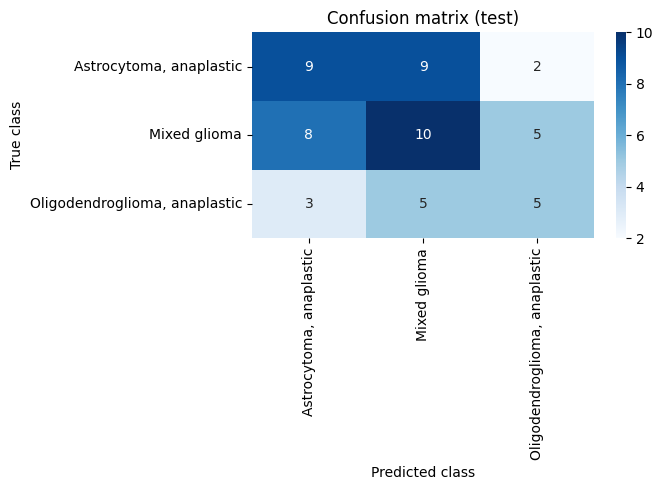


Чувствительность и специфичность по классам:


,class,sensitivity_recall,specificity
0,"Astrocytoma, anaplastic",0.450000,0.694444
1,Mixed glioma,0.434783,0.575758
2,"Oligodendroglioma, anaplastic",0.384615,0.837209


In [14]:
# Обучаем лучшую модель на всей train-выборке и оцениваем на test
best_pipe = best_objects[(best_subset_name, best_model_name)]
best_cols = feature_subsets[best_subset_name]

best_pipe.fit(X_train[best_cols], y_train_enc)

y_pred = best_pipe.predict(X_test[best_cols])
y_proba = best_pipe.predict_proba(X_test[best_cols])

# Основные метрики на тесте
test_bal_acc = balanced_accuracy_score(y_test_enc, y_pred)
test_f1_macro = f1_score(y_test_enc, y_pred, average='macro')
test_roc_auc = roc_auc_score(y_test_enc, y_proba, multi_class='ovr', average='weighted')

print('Лучшая модель:', best_model_name)
print('Подмножество признаков:', best_subset_name)
print('\nМетрики на тестовой выборке:')
print(f'balanced_accuracy = {test_bal_acc:.4f}')
print(f'f1_macro          = {test_f1_macro:.4f}')
print(f'roc_auc_ovr_w     = {test_roc_auc:.4f}')

print('\nClassification report:')
print(classification_report(y_test_enc, y_pred, target_names=class_names))

# Матрица ошибок
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion matrix (test)')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.tight_layout()
plt.show()

# Чувствительность (TPR) и специфичность (TNR) для каждого класса
metrics_by_class = []
N = cm.sum()

for i, cls_name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = N - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    metrics_by_class.append({
        'class': cls_name,
        'sensitivity_recall': sensitivity,
        'specificity': specificity
    })

metrics_by_class_df = pd.DataFrame(metrics_by_class)
print('\nЧувствительность и специфичность по классам:')
display(metrics_by_class_df)